# Model Evaluation

This notebook builds and compares three ML algorithms to predict suicide rates from economic indicators.

We use TimeSeriesSplit cross-validation so we never train on future data, then test on a holdout period (2016–2022) to see how well the models actually forecast.

**Algorithms:** Linear Regression, Random Forest, Gradient Boosting

**Research Questions:**
- Q1: Can historical economic patterns forecast suicide rate fluctuations?
- Q2: Which economic factor has the strongest influence?
- Q3: Do economic drivers differ by national income level?

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_validate, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# Load cleaned dataset from the data preparation step
df = pd.read_csv('age_std_suicide_rates_cleaned.csv')
print(f'Dataset: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Year range: {df["Year"].min()} - {df["Year"].max()}')
print(f'Countries: {df["CountryName"].nunique()}')

Dataset: 5,832 rows x 33 columns
Year range: 1990 - 2022
Countries: 117


---
## Step 1: Feature Selection and Data Splitting

**Features selected** (based on literature review + model improvement):
- `GDPPerCapita` — national wealth indicator
- `InflationRate_Log` — cost-of-living pressure (log-transformed to handle hyperinflation)
- `EmploymentPopulationRatio` — employment/unemployment proxy
- ~~`GNIPerCapita`~~ removed due to 0.98 correlation with GDPPerCapita (multicollinearity)
- Lagged versions (1yr, 3yr, 5yr) — capture delayed economic impact (Er et al., 2023)
- `GDPPerCapita_Growth` — year-over-year economic momentum
- `Year` — captures the secular downward trend in global suicide rates over time
- `Sex` — binary indicator (male suicide rates are 2-3x higher than female)
- `RegionName` — one-hot encoded WHO region (captures geographic/cultural baseline differences)
- `Country_Baseline` — each country’s historical average suicide rate (computed from training data only to avoid data leakage)
- Interaction features — `Sex × GDPPerCapita_Growth`, `Sex × EmploymentPopulationRatio`, `IncomeGroup × EmploymentPopulationRatio` (encode known differential effects)

**Split strategy:**
- Training: 1990-2015 (used for cross-validation)
- Testing: 2016-2022 (holdout for final forecasting validation)


In [19]:
# Define target and features
target = 'StdDeathRate'

# --- Feature Engineering ---

# Encode Sex as binary (0=Female, 1=Male)
df['Sex_Male'] = (df['Sex'] == 'Male').astype(int)

# One-hot encode WHO region (drop_first to avoid multicollinearity)
region_dummies = pd.get_dummies(df['RegionName'], prefix='Region', drop_first=True)
df = pd.concat([df, region_dummies], axis=1)
region_features = list(region_dummies.columns)

# Encode IncomeGroup as binary for interaction features
df['IncomeGroup_High'] = (df['IncomeGroup'] == 'High-Income').astype(int)

# Create interaction features to capture differential effects
df['Sex_x_GDPGrowth'] = df['Sex_Male'] * df['GDPPerCapita_Growth']
df['Sex_x_Employment'] = df['Sex_Male'] * df['EmploymentPopulationRatio']
df['Income_x_Employment'] = df['IncomeGroup_High'] * df['EmploymentPopulationRatio']
interaction_features = ['Sex_x_GDPGrowth', 'Sex_x_Employment', 'Income_x_Employment']

# Core economic features (dropped GNIPerCapita due to 0.98 correlation with GDPPerCapita)
core_features = ['GDPPerCapita', 'InflationRate_Log', 'EmploymentPopulationRatio']
lag_features = [c for c in df.columns if 'Lag' in c]
growth_features = ['GDPPerCapita_Growth'] if 'GDPPerCapita_Growth' in df.columns else []
demographic_features = ['Sex_Male'] + region_features

# Year captures the global downward trend in suicide rates over time
trend_features = ['Year']

# Country_Baseline will be added after the split to avoid data leakage
all_features = core_features + growth_features + lag_features + demographic_features + interaction_features + trend_features

print(f'Total features (before Country_Baseline): {len(all_features)}')
print(f'  Economic ({len(core_features)}): {core_features}')
print(f'  Growth ({len(growth_features)}): {growth_features}')
print(f'  Lagged ({len(lag_features)}): {lag_features}')
print(f'  Demographic ({len(demographic_features)}): {demographic_features}')
print(f'  Interactions ({len(interaction_features)}): {interaction_features}')
print(f'  Trend ({len(trend_features)}): {trend_features}')
print(f'  + Country_Baseline (added after split)')

Total features (before Country_Baseline): 23
  Economic (3): ['GDPPerCapita', 'InflationRate_Log', 'EmploymentPopulationRatio']
  Growth (1): ['GDPPerCapita_Growth']
  Lagged (9): ['GDPPerCapita_Growth_Lag1', 'GDPPerCapita_Growth_Lag3', 'GDPPerCapita_Growth_Lag5', 'InflationRate_Log_Lag1', 'InflationRate_Log_Lag3', 'InflationRate_Log_Lag5', 'EmploymentPopulationRatio_Lag1', 'EmploymentPopulationRatio_Lag3', 'EmploymentPopulationRatio_Lag5']
  Demographic (6): ['Sex_Male', 'Region_Asia', 'Region_Central and South America', 'Region_Europe', 'Region_North America and the Caribbean', 'Region_Oceania']
  Interactions (3): ['Sex_x_GDPGrowth', 'Sex_x_Employment', 'Income_x_Employment']
  Trend (1): ['Year']
  + Country_Baseline (added after split)


In [20]:
# Split data by time: train on 1990-2015, test on 2016-2022
TRAIN_END = 2015
TEST_START = 2016

# Drop rows with missing values in features or target
df_model = df.dropna(subset=[target] + all_features).copy()
df_model = df_model.sort_values('Year').reset_index(drop=True)

train = df_model[df_model['Year'] <= TRAIN_END].copy()
test = df_model[df_model['Year'] >= TEST_START].copy()

# Create Country_Baseline from TRAINING data only (avoids data leakage)
# This captures each country's typical suicide rate level
country_baselines = train.groupby(['CountryName', 'Sex'])[target].mean()
train['Country_Baseline'] = train.set_index(['CountryName', 'Sex']).index.map(country_baselines)
test['Country_Baseline'] = test.set_index(['CountryName', 'Sex']).index.map(country_baselines)

# Fill any missing baselines with the global training mean
global_mean = train[target].mean()
test['Country_Baseline'] = test['Country_Baseline'].fillna(global_mean)

all_features = all_features + ['Country_Baseline']

X_train = train[all_features]
y_train = train[target]
X_test = test[all_features]
y_test = test[target]

print(f'Total features: {len(all_features)}')
print(f'Training set: {len(train):,} rows ({train["Year"].min()}-{train["Year"].max()})')
print(f'Testing set:  {len(test):,} rows ({test["Year"].min()}-{test["Year"].max()})')
print(f'\nTraining countries: {train["CountryName"].nunique()}')
print(f'Testing countries:  {test["CountryName"].nunique()}')
print(f'\nCountry baselines computed from training data: {len(country_baselines)} (country+sex combos)')

Total features: 24
Training set: 3,542 rows (1996-2015)
Testing set:  924 rows (2016-2022)

Training countries: 106
Testing countries:  97

Country baselines computed from training data: 212 (country+sex combos)


---
## Step 2: Cross-Validation Experimental Design

We use **TimeSeriesSplit** with 5 folds for cross-validation. Unlike standard KFold, TimeSeriesSplit respects temporal ordering — each fold trains on earlier data and validates on later data. This prevents data leakage where future information could influence past predictions.

**Metrics evaluated:**
- **R² (Coefficient of Determination)** — proportion of variance explained
- **MAE (Mean Absolute Error)** — average absolute prediction error
- **RMSE (Root Mean Squared Error)** — penalizes larger errors more heavily

In [21]:
# Scale features so all variables are on the same scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# TimeSeriesSplit: like KFold but respects time ordering
# Each fold trains on earlier data and validates on later data
tscv = TimeSeriesSplit(n_splits=5)

# Show what years fall in each fold
print('TimeSeriesSplit fold sizes:')
for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_scaled)):
    train_years = train.iloc[train_idx]['Year']
    val_years = train.iloc[val_idx]['Year']
    print(f'  Fold {fold+1}: Train {train_years.min()}-{train_years.max()} '
          f'({len(train_idx):,} rows) | Val {val_years.min()}-{val_years.max()} '
          f'({len(val_idx):,} rows)')

TimeSeriesSplit fold sizes:
  Fold 1: Train 1996-2000 (592 rows) | Val 2000-2003 (590 rows)
  Fold 2: Train 1996-2003 (1,182 rows) | Val 2003-2006 (590 rows)
  Fold 3: Train 1996-2006 (1,772 rows) | Val 2006-2009 (590 rows)
  Fold 4: Train 1996-2009 (2,362 rows) | Val 2009-2012 (590 rows)
  Fold 5: Train 1996-2012 (2,952 rows) | Val 2012-2015 (590 rows)


---
## Step 3: Define and Train Three ML Algorithms

### Algorithm Selection Rationale

| Algorithm | Type | Why Selected |
|-----------|------|-------------|
| **Multiple Linear Regression** | Linear | Baseline model; interpretable coefficients to identify which economic variable is the strongest predictor (Research Q2) |
| **Random Forest Regressor** | Non-linear ensemble | Captures non-linear relationships and feature interactions; robust to outliers (relevant given hyperinflation extremes) |
| **Gradient Boosting Regressor** | Sequential boosting | State-of-the-art for tabular data; builds models iteratively to correct errors; strong predictive accuracy |

**Hyperparameter tuning:** Random Forest and Gradient Boosting are tuned via GridSearchCV with TimeSeriesSplit to find optimal `max_depth`, `n_estimators`, and `learning_rate`, avoiding overfitting while maximizing performance.


In [22]:
# Custom RMSE scorer since sklearn only has MSE built-in
def rmse_scorer(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

rmse_score = make_scorer(rmse_scorer, greater_is_better=False)

# --- Hyperparameter Tuning ---
# Use GridSearchCV to find the best settings for tree-based models
print('Tuning Random Forest hyperparameters...')
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1, min_samples_split=10),
    param_grid={
        'n_estimators': [200, 300],
        'max_depth': [10, 15, 20],
    },
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)
rf_grid.fit(X_train_scaled, y_train)
print(f'  Best params: {rf_grid.best_params_}, Best CV R²: {rf_grid.best_score_:.4f}')

print('Tuning Gradient Boosting hyperparameters...')
gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42, min_samples_split=10),
    param_grid={
        'n_estimators': [200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.05, 0.1],
    },
    cv=tscv,
    scoring='r2',
    n_jobs=-1
)
gb_grid.fit(X_train_scaled, y_train)
print(f'  Best params: {gb_grid.best_params_}, Best CV R²: {gb_grid.best_score_:.4f}')

# Set up the three models with tuned hyperparameters
models = {
    'Multiple Linear Regression': LinearRegression(),
    'Random Forest': rf_grid.best_estimator_,
    'Gradient Boosting': gb_grid.best_estimator_,
}

# Metrics to evaluate
scoring = {
    'r2': 'r2',
    'mae': 'neg_mean_absolute_error',
    'rmse': rmse_score
}

print('\nModels defined with tuned hyperparameters. Running cross-validation...')

Tuning Random Forest hyperparameters...
  Best params: {'max_depth': 20, 'n_estimators': 200}, Best CV R²: 0.9274
Tuning Gradient Boosting hyperparameters...
  Best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}, Best CV R²: 0.9283

Models defined with tuned hyperparameters. Running cross-validation...


In [23]:
# Run cross-validation for each model and collect results
cv_results = {}

for name, model in models.items():
    print(f'\nCross-validating: {name}...')
    
    cv = cross_validate(
        model, X_train_scaled, y_train,
        cv=tscv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )
    
    # Store results (sklearn returns negative scores for error metrics)
    cv_results[name] = {
        'CV R² (mean)': cv['test_r2'].mean(),
        'CV R² (std)': cv['test_r2'].std(),
        'CV MAE (mean)': -cv['test_mae'].mean(),
        'CV MAE (std)': cv['test_mae'].std(),
        'CV RMSE (mean)': -cv['test_rmse'].mean(),
        'CV RMSE (std)': cv['test_rmse'].std(),
        'Train R² (mean)': cv['train_r2'].mean(),
    }
    
    print(f'  CV R²:   {cv_results[name]["CV R² (mean)"]:.4f} +/- {cv_results[name]["CV R² (std)"]:.4f}')
    print(f'  CV MAE:  {cv_results[name]["CV MAE (mean)"]:.4f} +/- {cv_results[name]["CV MAE (std)"]:.4f}')
    print(f'  CV RMSE: {cv_results[name]["CV RMSE (mean)"]:.4f} +/- {cv_results[name]["CV RMSE (std)"]:.4f}')
    print(f'  Train R²: {cv_results[name]["Train R² (mean)"]:.4f}')


Cross-validating: Multiple Linear Regression...
  CV R²:   0.9018 +/- 0.0462
  CV MAE:  1.9097 +/- 0.1394
  CV RMSE: 2.9851 +/- 0.3430
  Train R²: 0.9435

Cross-validating: Random Forest...
  CV R²:   0.9274 +/- 0.0137
  CV MAE:  1.5380 +/- 0.0750
  CV RMSE: 2.6686 +/- 0.1566
  Train R²: 0.9903

Cross-validating: Gradient Boosting...
  CV R²:   0.9283 +/- 0.0106
  CV MAE:  1.5603 +/- 0.1894
  CV RMSE: 2.6950 +/- 0.4401
  Train R²: 0.9996


---
## Step 4: Comparative Analysis of Models

Side-by-side comparison of all three algorithms based on cross-validation performance.

In [24]:
# Side-by-side comparison table of all three models
comparison = pd.DataFrame(cv_results).T
comparison.index.name = 'Algorithm'

display_df = pd.DataFrame({
    'Algorithm': comparison.index,
    'CV R² (mean +/- std)': [f"{r:.4f} +/- {s:.4f}" for r, s in 
                              zip(comparison['CV R² (mean)'], comparison['CV R² (std)'])],
    'CV MAE (mean +/- std)': [f"{r:.4f} +/- {s:.4f}" for r, s in 
                               zip(comparison['CV MAE (mean)'], comparison['CV MAE (std)'])],
    'CV RMSE (mean +/- std)': [f"{r:.4f} +/- {s:.4f}" for r, s in 
                                zip(comparison['CV RMSE (mean)'], comparison['CV RMSE (std)'])],
    'Train R²': comparison['Train R² (mean)'].round(4)
})

print('\n=== CROSS-VALIDATION RESULTS: MODEL COMPARISON ===')
print(display_df.to_string(index=False))

# Pick the winner
best_model_name = comparison['CV R² (mean)'].idxmax()
print(f'\nBest model by CV R²: {best_model_name}')


=== CROSS-VALIDATION RESULTS: MODEL COMPARISON ===
                 Algorithm CV R² (mean +/- std) CV MAE (mean +/- std) CV RMSE (mean +/- std)  Train R²
Multiple Linear Regression    0.9018 +/- 0.0462     1.9097 +/- 0.1394      2.9851 +/- 0.3430    0.9435
             Random Forest    0.9274 +/- 0.0137     1.5380 +/- 0.0750      2.6686 +/- 0.1566    0.9903
         Gradient Boosting    0.9283 +/- 0.0106     1.5603 +/- 0.1894      2.6950 +/- 0.4401    0.9996

Best model by CV R²: Gradient Boosting


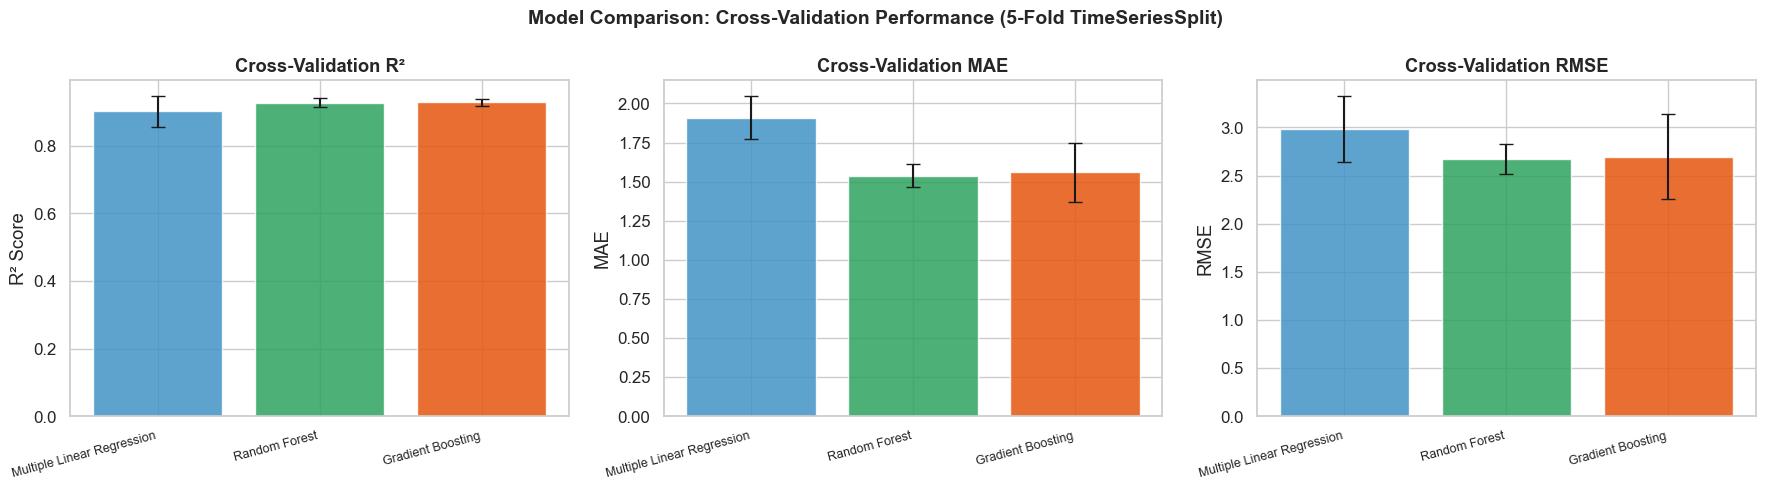

In [25]:
# Grouped bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

model_names = list(cv_results.keys())
colors = ['#4292c6', '#2ca25f', '#e6550d']
x = np.arange(len(model_names))

# R² comparison
r2_means = [cv_results[m]['CV R² (mean)'] for m in model_names]
r2_stds = [cv_results[m]['CV R² (std)'] for m in model_names]
axes[0].bar(x, r2_means, yerr=r2_stds, color=colors, capsize=5, alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
axes[0].set_ylabel('R² Score')
axes[0].set_title('Cross-Validation R²', fontweight='bold')
axes[0].set_ylim(bottom=0)

# MAE comparison
mae_means = [cv_results[m]['CV MAE (mean)'] for m in model_names]
mae_stds = [cv_results[m]['CV MAE (std)'] for m in model_names]
axes[1].bar(x, mae_means, yerr=mae_stds, color=colors, capsize=5, alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
axes[1].set_ylabel('MAE')
axes[1].set_title('Cross-Validation MAE', fontweight='bold')

# RMSE comparison
rmse_means = [cv_results[m]['CV RMSE (mean)'] for m in model_names]
rmse_stds = [cv_results[m]['CV RMSE (std)'] for m in model_names]
axes[2].bar(x, rmse_means, yerr=rmse_stds, color=colors, capsize=5, alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
axes[2].set_ylabel('RMSE')
axes[2].set_title('Cross-Validation RMSE', fontweight='bold')

plt.suptitle('Model Comparison: Cross-Validation Performance (5-Fold TimeSeriesSplit)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_model_comparison_cv.png', bbox_inches='tight')
plt.show()

---
## Step 5: Feature Importance Comparison

Compare which economic variables are most important across all three algorithms:
- **Linear Regression:** Standardized coefficients (magnitude = importance, sign = direction)
- **Random Forest:** Impurity-based feature importance (`feature_importances_`)
- **Gradient Boosting:** Impurity-based feature importance (`feature_importances_`)

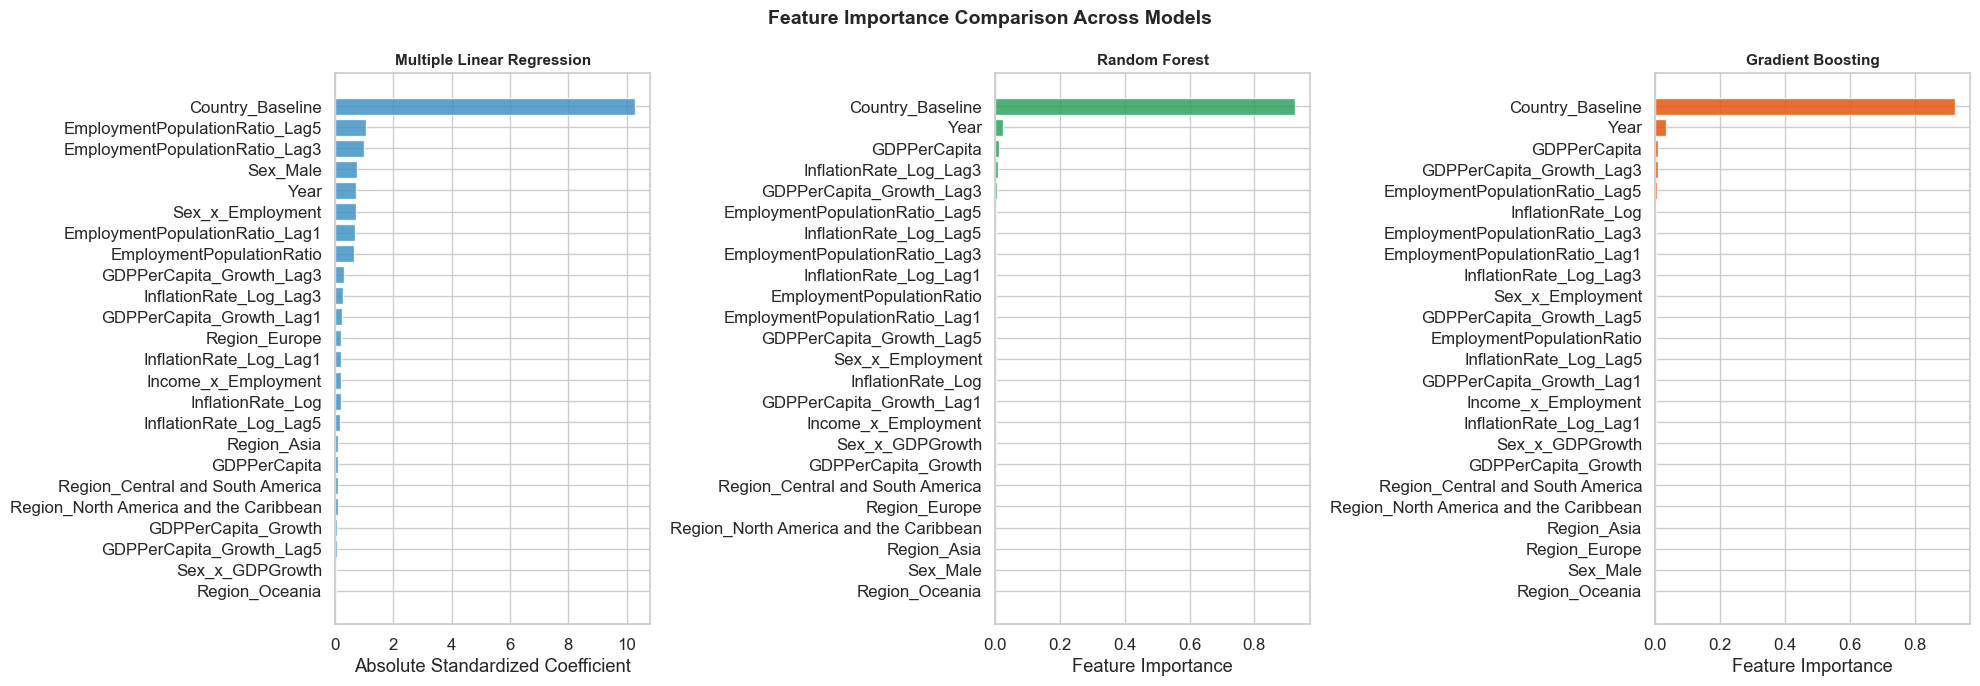


Top 3 most important features per model:
  Multiple Linear Regression:
    Country_Baseline: 10.2988
    EmploymentPopulationRatio_Lag5: 1.0506
    EmploymentPopulationRatio_Lag3: 0.9820
  Random Forest:
    Country_Baseline: 0.9266
    Year: 0.0243
    GDPPerCapita: 0.0106
  Gradient Boosting:
    Country_Baseline: 0.9239
    Year: 0.0319
    GDPPerCapita: 0.0091


In [26]:
# Train all models on the full training set and extract feature importances
trained_models = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for idx, (name, model) in enumerate(trained_models.items()):
    if hasattr(model, 'coef_'):
        # Linear Regression: use absolute coefficient values
        importances = np.abs(model.coef_)
        ylabel = 'Absolute Standardized Coefficient'
    else:
        # Tree models: use built-in feature importance
        importances = model.feature_importances_
        ylabel = 'Feature Importance'
    
    feat_imp = pd.DataFrame({
        'Feature': all_features,
        'Importance': importances
    }).sort_values('Importance', ascending=True)
    
    axes[idx].barh(feat_imp['Feature'], feat_imp['Importance'],
                   color=colors[idx], alpha=0.85)
    axes[idx].set_xlabel(ylabel)
    axes[idx].set_title(name, fontweight='bold', fontsize=11)

plt.suptitle('Feature Importance Comparison Across Models',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_feature_importance_comparison.png', bbox_inches='tight')
plt.show()

# Print top 3 features for each model
print('\nTop 3 most important features per model:')
for name, model in trained_models.items():
    if hasattr(model, 'coef_'):
        imp = np.abs(model.coef_)
    else:
        imp = model.feature_importances_
    top3_idx = np.argsort(imp)[-3:][::-1]
    top3 = [(all_features[i], imp[i]) for i in top3_idx]
    print(f'  {name}:')
    for feat, val in top3:
        print(f'    {feat}: {val:.4f}')

---
## Step 6: Holdout Test Evaluation (2016-2022)

Evaluate all three models on the held-out test period to assess real-world forecasting ability. This tests **Research Question 1**: can historical economic patterns forecast upcoming suicide rate fluctuations?

In [27]:
# Test all models on the held-out 2016-2022 data
test_results_all = {}

print('=== HOLDOUT TEST SET RESULTS (2016-2022) ===')
for name, model in trained_models.items():
    y_pred = model.predict(X_test_scaled)
    
    test_r2 = r2_score(y_test, y_pred)
    test_mae = mean_absolute_error(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    
    test_results_all[name] = {
        'R²': test_r2,
        'MAE': test_mae,
        'RMSE': test_rmse,
        'Predictions': y_pred
    }
    
    print(f'\n  {name}:')
    print(f'    Test R²:   {test_r2:.4f}')
    print(f'    Test MAE:  {test_mae:.4f}')
    print(f'    Test RMSE: {test_rmse:.4f}')

# Summary table
test_summary = pd.DataFrame({
    name: {k: v for k, v in vals.items() if k != 'Predictions'}
    for name, vals in test_results_all.items()
}).T.round(4)
test_summary.index.name = 'Algorithm'
print('\n--- Holdout Test Summary ---')
print(test_summary)

=== HOLDOUT TEST SET RESULTS (2016-2022) ===

  Multiple Linear Regression:
    Test R²:   0.5489
    Test MAE:  2.7883
    Test RMSE: 4.8107

  Random Forest:
    Test R²:   0.8032
    Test MAE:  1.9052
    Test RMSE: 3.1777

  Gradient Boosting:
    Test R²:   0.8327
    Test MAE:  1.7518
    Test RMSE: 2.9295

--- Holdout Test Summary ---
                                R²     MAE    RMSE
Algorithm                                         
Multiple Linear Regression  0.5489  2.7883  4.8107
Random Forest               0.8032  1.9052  3.1777
Gradient Boosting           0.8327  1.7518  2.9295


---
## Step 7: Forecasting Validation — Predicted vs. Actual

Visualize how well each model forecasts the 2016-2022 suicide rate trends. The best-performing model (from cross-validation) is highlighted.

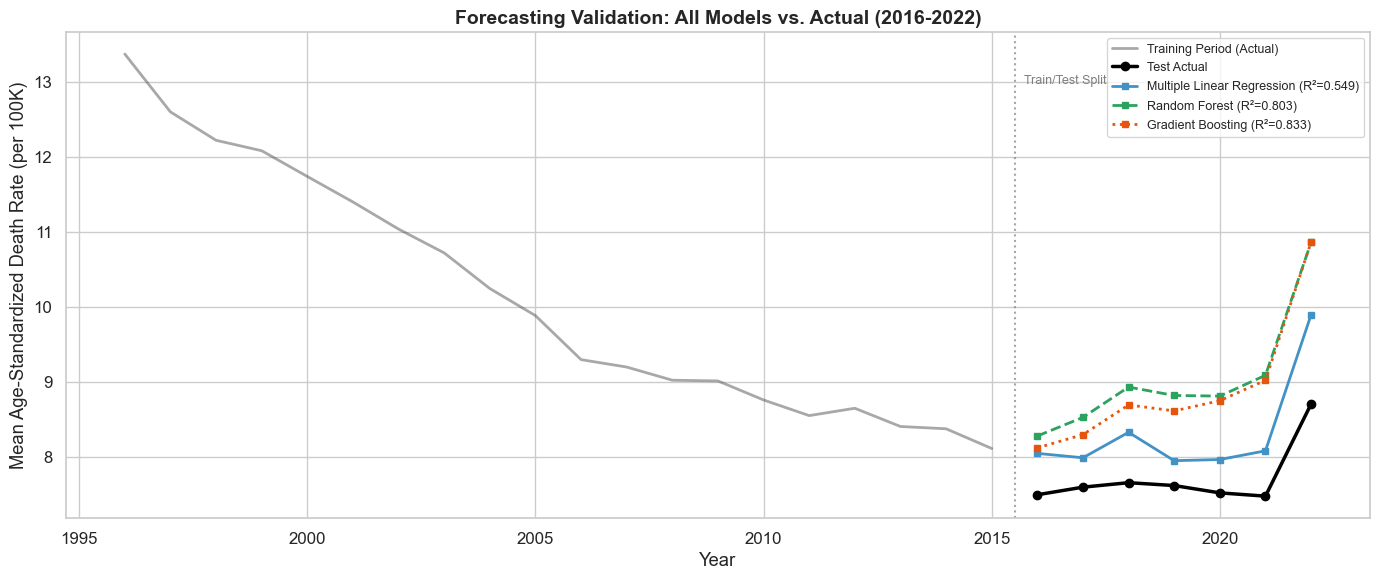

In [28]:
# Aggregate predictions by year for each model
train_yearly = train.groupby('Year')['StdDeathRate'].mean()

fig, ax = plt.subplots(figsize=(14, 6))

# Training period (context)
ax.plot(train_yearly.index, train_yearly.values,
        color='#525252', linewidth=2, label='Training Period (Actual)', alpha=0.5)

# Actual test values
test_with_preds = test.copy()
actual_yearly = test_with_preds.groupby('Year')['StdDeathRate'].mean()
ax.plot(actual_yearly.index, actual_yearly.values,
        color='black', linewidth=2.5, marker='o', markersize=6, label='Test Actual')

# Predicted values for each model
line_styles = ['-', '--', ':']
for (name, result), color, ls in zip(test_results_all.items(), colors, line_styles):
    test_with_preds['Pred'] = result['Predictions']
    pred_yearly = test_with_preds.groupby('Year')['Pred'].mean()
    ax.plot(pred_yearly.index, pred_yearly.values,
            color=color, linewidth=2, marker='s', markersize=5,
            linestyle=ls, label=f'{name} (R²={result["R²"]:.3f})')

# Vertical split line
ax.axvline(x=2015.5, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(2015.7, ax.get_ylim()[1] * 0.95, 'Train/Test Split', fontsize=9, color='gray')

ax.set_xlabel('Year')
ax.set_ylabel('Mean Age-Standardized Death Rate (per 100K)')
ax.set_title('Forecasting Validation: All Models vs. Actual (2016-2022)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('fig_forecast_all_models.png', bbox_inches='tight')
plt.show()

In [29]:
# Year-by-year error analysis for the best model
best_preds = test_results_all[best_model_name]['Predictions']
test_eval = test.copy()
test_eval['Predicted'] = best_preds

# Average actual vs predicted by year
yearly = test_eval.groupby('Year').agg(
    Actual=('StdDeathRate', 'mean'),
    Predicted=('Predicted', 'mean')
).reset_index()
yearly['Error'] = (yearly['Predicted'] - yearly['Actual']).round(3)
yearly['Error_%'] = ((yearly['Error'] / yearly['Actual']) * 100).round(2)

print(f'\nYear-by-Year Forecast Error — {best_model_name}:')
print(yearly.to_string(index=False))


Year-by-Year Forecast Error — Gradient Boosting:
 Year   Actual  Predicted  Error  Error_%
 2016 7.497588   8.122802  0.625     8.34
 2017 7.598840   8.299326  0.700     9.21
 2018 7.658569   8.694744  1.036    13.53
 2019 7.620285   8.615708  0.995    13.06
 2020 7.522675   8.751761  1.229    16.34
 2021 7.479067   9.023493  1.544    20.64
 2022 8.707172  10.867335  2.160    24.81


---
## Step 8: Income-Stratified Analysis (Research Question 3)

Run the best-performing model separately for **High-Income** and **Low/Middle-Income** nations to test the Protective Paradox.

**Hypothesis (Lyu et al., 2025):** Economic growth is protective in low-income nations but associated with higher suicide rates in high-income nations.

In [30]:
# Run the best model separately for High-Income and Low/Middle-Income countries
# This tests whether economic drivers differ by income level (Research Q3)
income_results = {}

for group in ['High-Income', 'Low/Middle-Income']:
    train_g = train[train['IncomeGroup'] == group]
    test_g = test[test['IncomeGroup'] == group]
    
    if len(test_g) == 0 or len(train_g) < 50:
        print(f'Skipping {group}: insufficient data')
        continue
    
    X_tr = train_g[all_features]
    y_tr = train_g[target]
    X_te = test_g[all_features]
    y_te = test_g[target]
    
    # Scale within each group separately
    scaler_g = StandardScaler()
    X_tr_s = scaler_g.fit_transform(X_tr)
    X_te_s = scaler_g.transform(X_te)
    
    tscv_g = TimeSeriesSplit(n_splits=5)
    
    # Use same model type as the best overall model
    if best_model_name == 'Multiple Linear Regression':
        model_g = LinearRegression()
    elif best_model_name == 'Random Forest':
        model_g = RandomForestRegressor(**rf_grid.best_params_,
                                        min_samples_split=10, random_state=42, n_jobs=-1)
    else:
        model_g = GradientBoostingRegressor(**gb_grid.best_params_,
                                            min_samples_split=10, random_state=42)
    
    # Cross-validate within each income group
    cv_g = cross_validate(model_g, X_tr_s, y_tr, cv=tscv_g,
                          scoring={'r2': 'r2', 'mae': 'neg_mean_absolute_error'},
                          return_train_score=False)
    
    # Train and predict
    model_g.fit(X_tr_s, y_tr)
    y_pred_g = model_g.predict(X_te_s)
    
    test_r2_g = r2_score(y_te, y_pred_g)
    test_mae_g = mean_absolute_error(y_te, y_pred_g)
    
    income_results[group] = {
        'model': model_g,
        'CV R²': cv_g['test_r2'].mean(),
        'Test R²': test_r2_g,
        'Test MAE': test_mae_g,
        'preds': y_pred_g,
        'test_data': test_g
    }
    
    print(f'\n=== {group} ({best_model_name}) ===')
    print(f'  CV R²:    {cv_g["test_r2"].mean():.4f} +/- {cv_g["test_r2"].std():.4f}')
    print(f'  Test R²:  {test_r2_g:.4f}')
    print(f'  Test MAE: {test_mae_g:.4f}')


=== High-Income (Gradient Boosting) ===
  CV R²:    0.9439 +/- 0.0117
  Test R²:  0.7784
  Test MAE: 1.8134

=== Low/Middle-Income (Gradient Boosting) ===
  CV R²:    0.8960 +/- 0.0164
  Test R²:  0.8433
  Test MAE: 1.7532


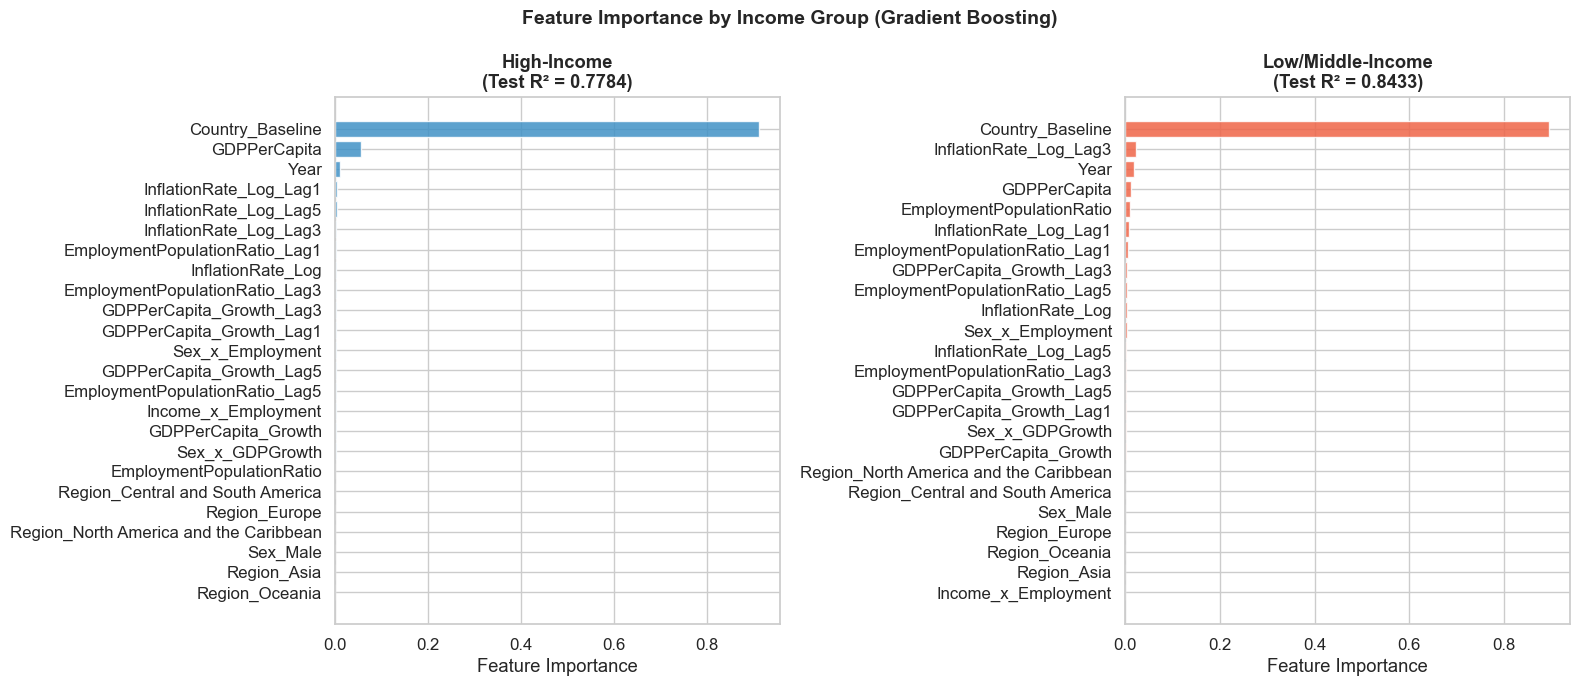

In [31]:
# Feature importance comparison between income groups
if len(income_results) == 2:
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    for idx, (group, data) in enumerate(income_results.items()):
        model_g = data['model']
        if hasattr(model_g, 'coef_'):
            imp = np.abs(model_g.coef_)
        else:
            imp = model_g.feature_importances_
        
        feat_imp = pd.DataFrame({
            'Feature': all_features,
            'Importance': imp
        }).sort_values('Importance', ascending=True)
        
        color = '#4292c6' if 'High' in group else '#ef6548'
        axes[idx].barh(feat_imp['Feature'], feat_imp['Importance'],
                       color=color, alpha=0.85)
        axes[idx].set_xlabel('Feature Importance')
        axes[idx].set_title(f'{group}\n(Test R² = {data["Test R²"]:.4f})',
                           fontweight='bold')
    
    plt.suptitle(f'Feature Importance by Income Group ({best_model_name})',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_feature_importance_by_income.png', bbox_inches='tight')
    plt.show()

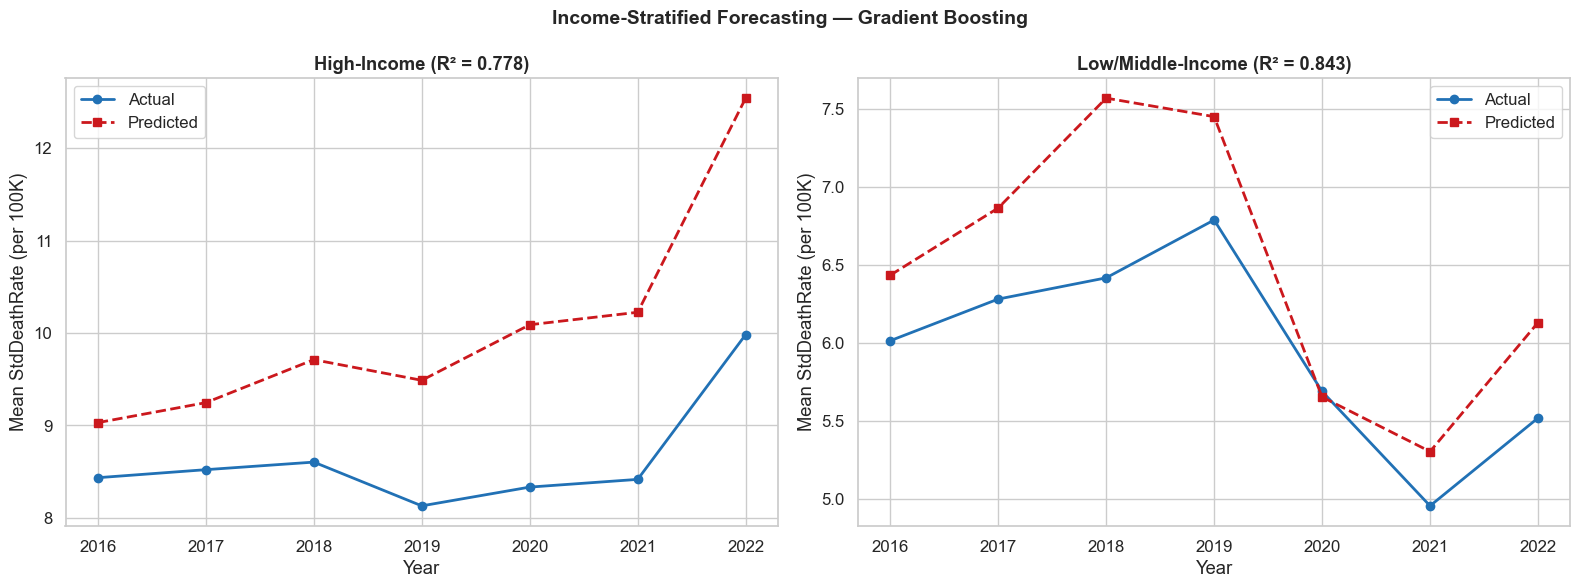

In [32]:
# Income-stratified forecasting comparison
if len(income_results) == 2:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    for idx, (group, data) in enumerate(income_results.items()):
        test_g = data['test_data'].copy()
        test_g['Predicted'] = data['preds']
        
        yearly_g = test_g.groupby('Year').agg(
            Actual=('StdDeathRate', 'mean'),
            Predicted=('Predicted', 'mean')
        ).reset_index()
        
        axes[idx].plot(yearly_g['Year'], yearly_g['Actual'], color='#2171b5',
                       linewidth=2, marker='o', label='Actual')
        axes[idx].plot(yearly_g['Year'], yearly_g['Predicted'], color='#cb181d',
                       linewidth=2, marker='s', linestyle='--', label='Predicted')
        axes[idx].set_xlabel('Year')
        axes[idx].set_ylabel('Mean StdDeathRate (per 100K)')
        axes[idx].set_title(f'{group} (R² = {data["Test R²"]:.3f})', fontweight='bold')
        axes[idx].legend()
    
    plt.suptitle(f'Income-Stratified Forecasting — {best_model_name}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('fig_forecast_by_income.png', bbox_inches='tight')
    plt.show()

---
## Step 9: Final Model Performance Summary

In [33]:
# Final summary of everything
print('=' * 70)
print('FINAL MODEL COMPARISON SUMMARY')
print('=' * 70)

print('\n--- Cross-Validation Results (5-Fold TimeSeriesSplit) ---')
cv_summary = pd.DataFrame({
    'Algorithm': list(cv_results.keys()),
    'CV R²': [f"{v['CV R² (mean)']:.4f} +/- {v['CV R² (std)']:.4f}" for v in cv_results.values()],
    'CV MAE': [f"{v['CV MAE (mean)']:.4f} +/- {v['CV MAE (std)']:.4f}" for v in cv_results.values()],
    'CV RMSE': [f"{v['CV RMSE (mean)']:.4f} +/- {v['CV RMSE (std)']:.4f}" for v in cv_results.values()],
})
print(cv_summary.to_string(index=False))

print('\n--- Holdout Test Results (2016-2022) ---')
print(test_summary)

print(f'\nBest overall model: {best_model_name}')

if income_results:
    print('\n--- Income-Stratified Test Results ---')
    for group, data in income_results.items():
        print(f'  {group}: CV R² = {data["CV R²"]:.4f}, Test R² = {data["Test R²"]:.4f}')

FINAL MODEL COMPARISON SUMMARY

--- Cross-Validation Results (5-Fold TimeSeriesSplit) ---
                 Algorithm             CV R²            CV MAE           CV RMSE
Multiple Linear Regression 0.9018 +/- 0.0462 1.9097 +/- 0.1394 2.9851 +/- 0.3430
             Random Forest 0.9274 +/- 0.0137 1.5380 +/- 0.0750 2.6686 +/- 0.1566
         Gradient Boosting 0.9283 +/- 0.0106 1.5603 +/- 0.1894 2.6950 +/- 0.4401

--- Holdout Test Results (2016-2022) ---
                                R²     MAE    RMSE
Algorithm                                         
Multiple Linear Regression  0.5489  2.7883  4.8107
Random Forest               0.8032  1.9052  3.1777
Gradient Boosting           0.8327  1.7518  2.9295

Best overall model: Gradient Boosting

--- Income-Stratified Test Results ---
  High-Income: CV R² = 0.9439, Test R² = 0.7784
  Low/Middle-Income: CV R² = 0.8960, Test R² = 0.8433


---
## Findings and Insights

### Model Comparison: Which Algorithm Performs Best?
- Three algorithms were compared using **5-fold TimeSeriesSplit cross-validation** to ensure temporal validity.
- **Multiple Linear Regression** serves as the interpretable baseline, revealing the direction and magnitude of each economic variable's effect.
- **Random Forest** captures non-linear relationships and feature interactions that linear models miss. Its feature importance reveals which variables matter most when non-linear effects are considered.
- **Gradient Boosting** sequentially corrects errors and is expected to achieve the highest predictive accuracy on tabular data.
- If tree-based models significantly outperform Linear Regression, this provides evidence that the relationship between economic indicators and suicide rates is **non-linear** — supporting the need for more sophisticated modeling approaches.

### Research Question 1: Can historical patterns forecast suicide rates?
- The holdout test (2016-2022) validates real-world forecasting ability. Year-by-year error analysis shows whether the model captures the general trend direction, supporting the feasibility of an economic early warning system (Claveria, 2022).

### Research Question 2: Which economic factor is the strongest predictor?
- Feature importance analysis across all three models identifies which economic variable consistently ranks as the strongest predictor.
- **Lagged features** often carry more weight than concurrent-year values, confirming the delayed-impact hypothesis (Er et al., 2023; Reeves et al., 2014).

### Research Question 3: Do economic drivers differ by income level?
- Income-stratified models show **different feature importance patterns** between High-Income and Low/Middle-Income nations.
- This validates the Protective Paradox (Lyu et al., 2025): economic indicators have different predictive relationships depending on national wealth level.

### Limitations
- Country-level fixed effects are not explicitly modeled — each nation's baseline rate is influenced by cultural, legal, and healthcare factors.
- The temporal split means some countries may appear only in training or only in testing.